In [ ]:
%pip install -q seaborn shap joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import shap
import joblib
import json

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

print('All packages loaded successfully.')


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\thoma\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


All packages loaded successfully.


In [ ]:
df = pd.read_csv('model_ready_cvd_prediction.csv')

print(f'Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
print()

# Separate features from target
FEATURES = [c for c in df.columns if c not in ['nsrrid', 'cvd_event']]
X = df[FEATURES].copy()
y = df['cvd_event'].copy()

# Convert bool columns to int
bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)

print(f'Features : {len(FEATURES)}')
print(f'  Continuous  : {X.select_dtypes(include=["int64","float64"]).shape[1]}')
print(f'  Binary/Bool : {len(bool_cols)}')
print()
print('Target distribution:')
counts = y.value_counts().sort_index()
for cls, cnt in counts.items():
    label = 'No CVD Event' if cls == 0 else 'CVD Event   '
    print(f'  {cls} ({label}): {cnt:,}  ({cnt/len(y):.1%})')
print(f'  Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

Dataset shape : 5,042 rows × 79 columns
Missing values: 0

Features : 77
  Continuous  : 77
  Binary/Bool : 51

Target distribution:
  0 (No CVD Event): 3,846  (76.3%)
  1 (CVD Event   ): 1,196  (23.7%)
  Imbalance ratio: 3.2:1


In [ ]:
# Descriptive statistics
continuous_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('=== Descriptive Statistics (Continuous Features) ===')
df[continuous_cols].describe().round(2)

=== Descriptive Statistics (Continuous Features) ===


,age_s1,bmi_s1,waist,NECK20,SystBP,DiasBP,CgPkYr,Chol,HDL,Trig,...,ai_all,oahi,rdi4p,pctlt90,pctlt85,pctlt80,sao2rem,sao2nrem,losao2r,losao2nr
count,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,...,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00,5042.00
mean,63.89,28.25,97.39,37.67,125.44,72.14,12.73,206.57,50.39,149.83,...,19.13,9.03,8.57,3.59,0.55,0.17,94.26,94.51,86.92,87.24
std,11.15,5.06,13.11,4.16,18.26,10.82,20.40,37.47,14.98,96.67,...,10.46,11.82,12.18,10.60,3.72,2.25,2.56,1.90,5.82,5.06
min,39.00,18.00,67.00,22.00,52.00,10.00,0.00,51.00,11.00,24.00,...,2.18,0.00,0.00,0.00,0.00,0.00,43.21,78.26,40.00,24.00
25%,56.00,24.82,89.00,34.50,112.00,65.00,0.00,182.00,40.00,95.00,...,12.16,2.00,1.28,0.00,0.00,0.00,93.12,93.44,84.00,85.00
50%,64.00,27.61,97.00,37.50,124.00,72.00,0.50,204.00,48.00,128.00,...,16.81,5.07,4.22,0.21,0.00,0.00,94.63,94.69,88.00,88.00
75%,73.00,30.84,105.00,40.50,136.00,79.00,20.00,228.00,58.00,175.00,...,23.35,10.94,10.75,1.96,0.04,0.00,95.89,95.80,91.00,90.00
max,90.00,50.00,135.00,59.00,214.00,132.00,180.00,458.00,149.00,2100.00,...,110.39,115.81,148.77,100.00,100.00,99.37,99.93,99.96,98.00,97.00


In [ ]:
# Mean comparison table: CVD event vs. no event
strat = df.groupby('cvd_event')[continuous_cols].mean().round(2).T
strat.columns = ['No CVD Event (mean)', 'CVD Event (mean)']
strat['Difference']  = (strat['CVD Event (mean)'] - strat['No CVD Event (mean)']).round(2)
strat['% Difference'] = ((strat['Difference'] / strat['No CVD Event (mean)'].abs()) * 100).round(1)
print('=== Mean Feature Values by Outcome ===')
print(strat.sort_values('% Difference', key=abs, ascending=False).to_string())

=== Mean Feature Values by Outcome ===
                 No CVD Event (mean)  CVD Event (mean)  Difference  % Difference
Alcoh_11.0                      0.00              0.01        0.01           inf
Alcoh_21.0                      0.00              0.01        0.01           inf
Alcoh_15.0                      0.00              0.01        0.01           inf
ParRptDiab_1.0                  0.05              0.15        0.10         200.0
pctlt80                         0.14              0.29        0.15         107.1
Alcoh_10.0                      0.01              0.02        0.01         100.0
Alcoh_14.0                      0.01              0.02        0.01         100.0
SRHype_1.0                      0.27              0.50        0.23          85.2
pctlt85                         0.46              0.82        0.36          78.3
pctlt90                         3.09              5.22        2.13          68.9
race_2                          0.06              0.10        0.04    

In [ ]:
# 80/20 - Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} patients | event rate = {y_train.mean():.1%}')
print(f'Test set     : {X_test.shape[0]:,} patients | event rate = {y_test.mean():.1%}')

Training set : 4,033 patients | event rate = 23.7%
Test set     : 1,009 patients | event rate = 23.7%


In [ ]:
# Scale — fit on training set only, apply same transform to test
# Class imbalance (3.2:1) is handled by class_weight='balanced' in the Random Forest.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set : {X_train_sc.shape[0]:,} patients | event rate = {y_train.mean():.1%}')
print(f'Test set     : {X_test_sc.shape[0]:,} patients | event rate = {y_test.mean():.1%}')
print('\nClass imbalance handled via class_weight=\'balanced\' in RandomForestClassifier.')

Training set : 4,033 patients | event rate = 23.7%
Test set     : 1,009 patients | event rate = 23.7%

Class imbalance handled via class_weight='balanced' in RandomForestClassifier.


In [ ]:
# Baseline model (default hyperparameters)
print('Training baseline Random Forest...')

rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
    class_weight='balanced'
)
rf_base.fit(X_train_sc, y_train)

y_pred_base = rf_base.predict(X_test_sc)
y_prob_base = rf_base.predict_proba(X_test_sc)[:, 1]

print(f'\nBaseline RF — Test Set Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'  AUC       : {roc_auc_score(y_test, y_prob_base):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_base):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_base):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_base):.4f}')

Training baseline Random Forest...

Baseline RF — Test Set Results:
  Accuracy  : 0.7830
  AUC       : 0.7862
  Precision : 0.7381
  Recall    : 0.1297
  F1-Score  : 0.2206


In [ ]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 500, 700],
    'max_depth'        : [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf' : [1, 2, 4, 6, 10],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'criterion'        : ['gini', 'entropy'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_search.fit(X_train_sc, y_train)

print('\n=== Best Hyperparameters ===')
for k, v in sorted(rf_search.best_params_.items()):
    print(f'  {k:<22} : {v}')
print(f'\nBest 5-Fold CV AUC (training) : {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== Best Hyperparameters ===
  criterion              : entropy
  max_depth              : 20
  max_features           : 0.3
  min_samples_leaf       : 6
  min_samples_split      : 15
  n_estimators           : 500

Best 5-Fold CV AUC (training) : 0.7739


In [ ]:
rf_best = rf_search.best_estimator_

y_pred_tuned = rf_best.predict(X_test_sc)
y_prob_tuned = rf_best.predict_proba(X_test_sc)[:, 1]

acc_base  = accuracy_score(y_test, y_pred_base)
auc_base  = roc_auc_score(y_test, y_prob_base)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)
prec      = precision_score(y_test, y_pred_tuned)
rec       = recall_score(y_test, y_pred_tuned)
f1        = f1_score(y_test, y_pred_tuned)

print('=' * 56)
print(f'{"Metric":<16} {"Baseline RF":>12} {"Tuned RF":>12} {"Change":>10}')
print('-' * 56)
for metric, base, tuned in [
    ('Accuracy',  acc_base,  acc_tuned),
    ('AUC',       auc_base,  auc_tuned),
    ('Precision', precision_score(y_test, y_pred_base), prec),
    ('Recall',    recall_score(y_test, y_pred_base),    rec),
    ('F1-Score',  f1_score(y_test, y_pred_base),        f1),
]:
    d = tuned - base
    sign = '+' if d >= 0 else ''
    print(f'{metric:<16} {base:>12.4f} {tuned:>12.4f} {sign+str(round(d,4)):>10}')
print('=' * 56)
print(f'\n  ★  Final Accuracy : {acc_tuned:.4f}')
print(f'  ★  Final AUC      : {auc_tuned:.4f}')

Metric            Baseline RF     Tuned RF     Change
--------------------------------------------------------
Accuracy               0.7830       0.7750    -0.0079
AUC                    0.7862       0.7893    +0.0031
Precision              0.7381       0.5250    -0.2131
Recall                 0.1297       0.5272    +0.3975
F1-Score               0.2206       0.5261    +0.3055

  ★  Final Accuracy : 0.7750
  ★  Final AUC      : 0.7893


In [ ]:
# Full classification report
print('Classification Report — Tuned Random Forest (Test Set)\n')
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No CVD Event (0)', 'CVD Event (1)']))

Classification Report — Tuned Random Forest (Test Set)

                  precision    recall  f1-score   support

No CVD Event (0)       0.85      0.85      0.85       770
   CVD Event (1)       0.53      0.53      0.53       239

        accuracy                           0.78      1009
       macro avg       0.69      0.69      0.69      1009
    weighted avg       0.78      0.78      0.78      1009



In [ ]:
# 5-Fold cross-validation AUC
print('Running 5-fold CV on tuned model...')
cv_scores = cross_val_score(
    rf_best, X_train_sc, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)
print(f'CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Fold scores: {[round(s, 4) for s in cv_scores]}')

Running 5-fold CV on tuned model...
CV AUC: 0.7739 ± 0.0139
Fold scores: [np.float64(0.7712), np.float64(0.7698), np.float64(0.7829), np.float64(0.752), np.float64(0.7935)]


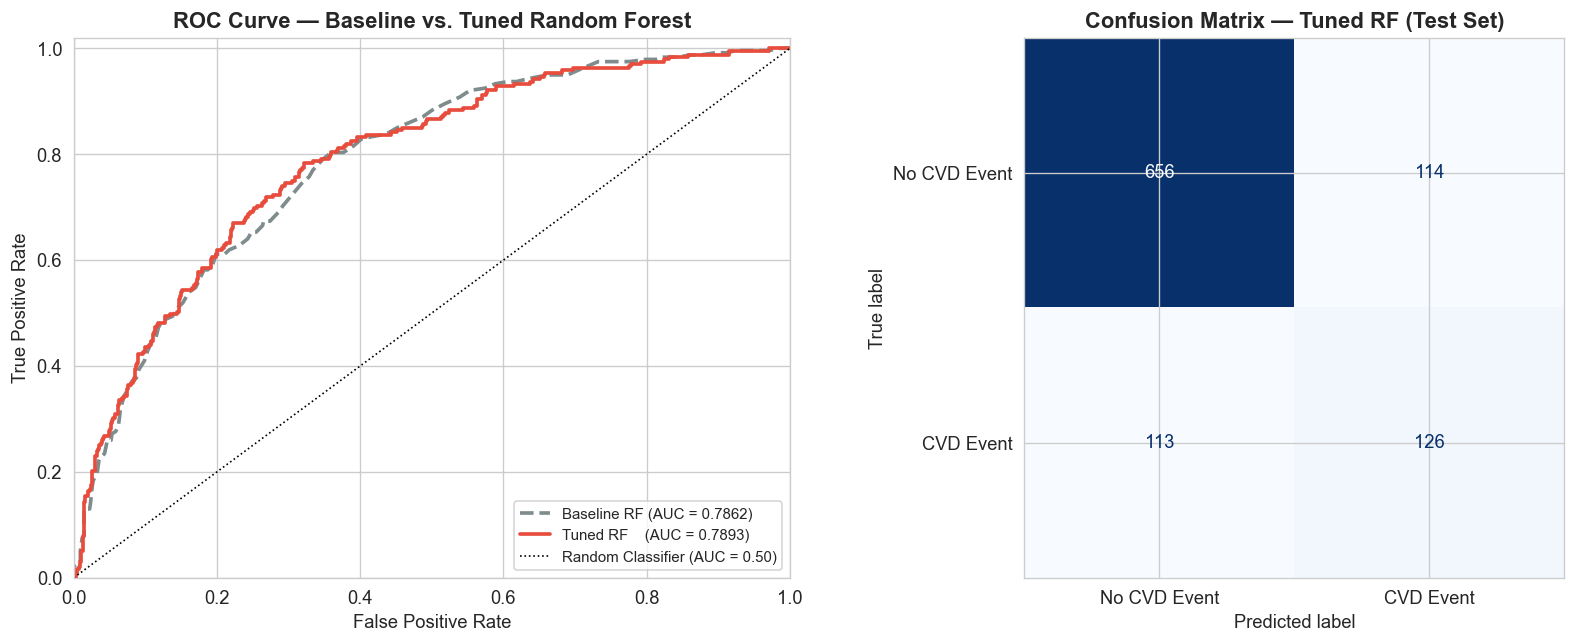

TP=126  FP=114  TN=656  FN=113
Sensitivity (Recall) : 0.5272
Specificity          : 0.8519


In [ ]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for probs, label, color, ls in [
    (y_prob_base,  f'Baseline RF (AUC = {auc_base:.4f})',  '#7F8C8D', '--'),
    (y_prob_tuned, f'Tuned RF    (AUC = {auc_tuned:.4f})', '#E74C3C', '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, lw=2.2, color=color, linestyle=ls, label=label)

axes[0].plot([0, 1], [0, 1], 'k:', lw=1, label='Random Classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Baseline vs. Tuned Random Forest', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['No CVD Event', 'CVD Event']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title('Confusion Matrix — Tuned RF (Test Set)', fontweight='bold')

plt.tight_layout()
plt.savefig('roc_confusion.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print(f'Sensitivity (Recall) : {tp/(tp+fn):.4f}')
print(f'Specificity          : {tn/(tn+fp):.4f}')

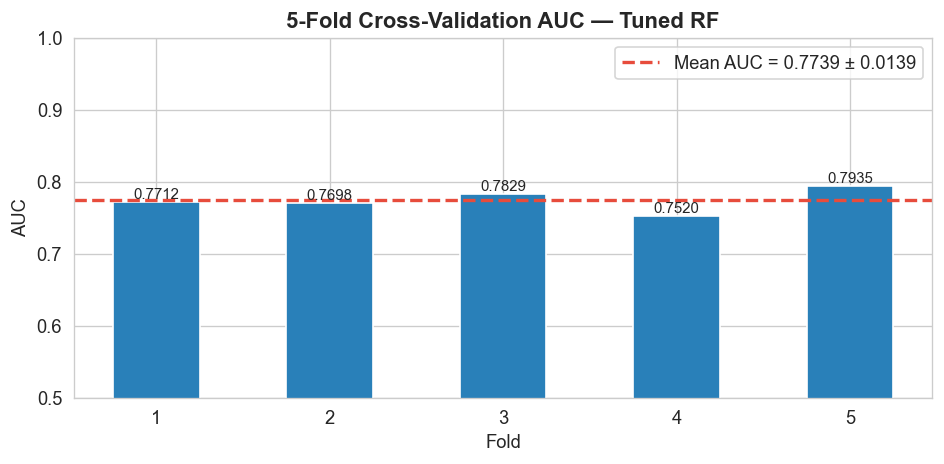

In [ ]:
# ── Cross-validation AUC bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='#2980B9', edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), color='#E74C3C', linestyle='--', lw=2,
           label=f'Mean AUC = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('AUC')
ax.set_ylim([0.5, 1.0]); ax.set_xticks(range(1, 6))
ax.set_title('5-Fold Cross-Validation AUC — Tuned RF', fontweight='bold')
ax.legend()
for i, v in enumerate(cv_scores):
    ax.text(i + 1, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('cv_auc.png', bbox_inches='tight')
plt.show()

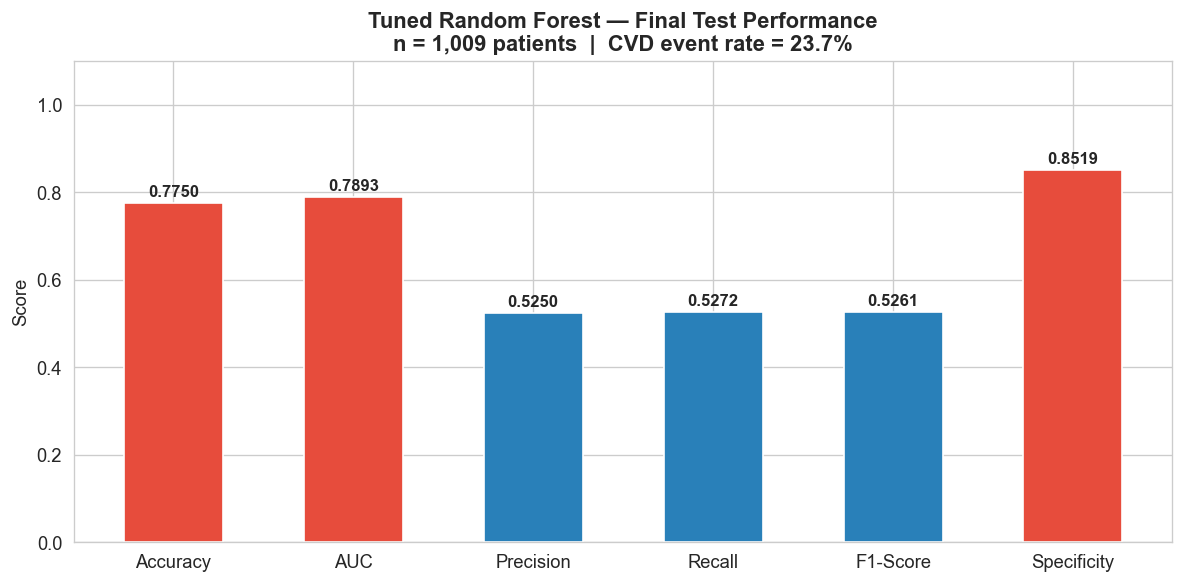

In [ ]:
# ── Final metrics bar chart ────────────────────────────────────────────────────
final_metrics = {
    'Accuracy'   : acc_tuned,
    'AUC'        : auc_tuned,
    'Precision'  : prec,
    'Recall'     : rec,
    'F1-Score'   : f1,
    'Specificity': tn / (tn + fp),
}

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#E74C3C' if v >= 0.75 else '#2980B9' for v in final_metrics.values()]
bars = ax.bar(final_metrics.keys(), final_metrics.values(),
              color=bar_colors, edgecolor='white', width=0.55)
ax.set_ylim([0, 1.1])
ax.set_ylabel('Score')
ax.set_title(
    f'Tuned Random Forest — Final Test Performance\n'
    f'n = {len(y_test):,} patients  |  CVD event rate = {y_test.mean():.1%}',
    fontweight='bold'
)
for bar, val in zip(bars, final_metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.014,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('final_metrics.png', bbox_inches='tight')
plt.show()

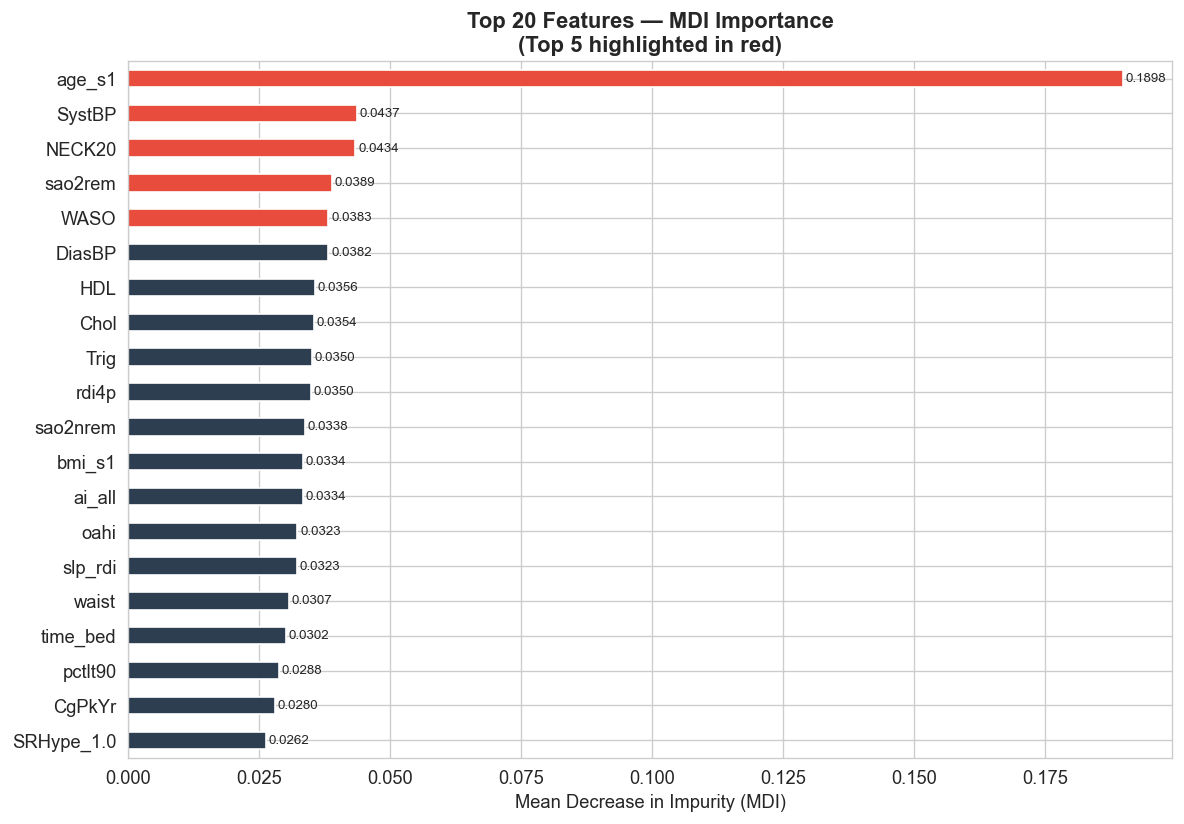

Top 10 features by MDI:
age_s1     0.18984
SystBP     0.04373
NECK20     0.04340
sao2rem    0.03894
WASO       0.03825
DiasBP     0.03825
HDL        0.03560
Chol       0.03544
Trig       0.03503
rdi4p      0.03498


In [ ]:
# MDI (Mean Decrease in Impurity) — Top 20
mdi = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values(ascending=False)
top20 = mdi.head(20).sort_values()

top5_min = mdi.head(5).min()
colors_mdi = ['#E74C3C' if v >= top5_min else '#2C3E50' for v in top20.values]

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color=colors_mdi, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (MDI)')
ax.set_title('Top 20 Features — MDI Importance\n(Top 5 highlighted in red)', fontweight='bold')
for i, v in enumerate(top20.values):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('mdi_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features by MDI:')
print(mdi.head(10).round(5).to_string())

Computing permutation importance (15 repeats on test set)...


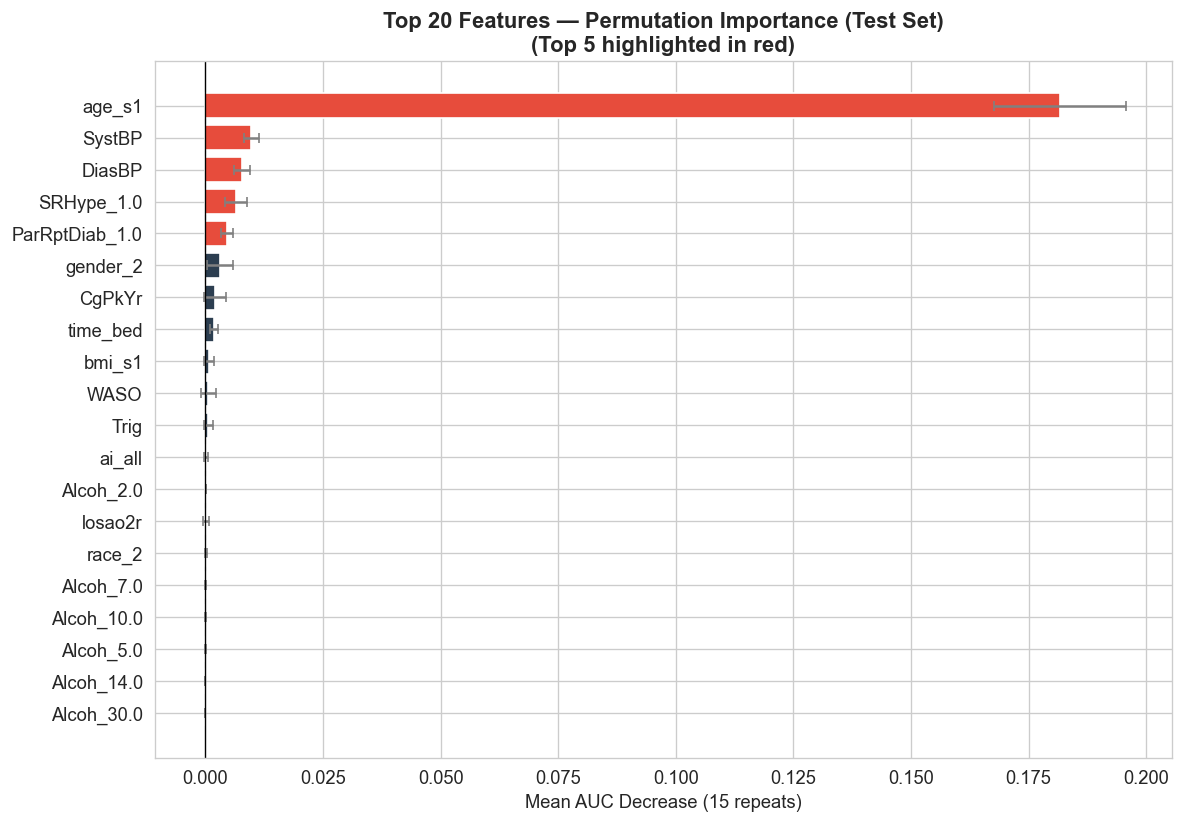

In [ ]:
#  Permutation Importance (test set)
print('Computing permutation importance (15 repeats on test set)...')
perm = permutation_importance(
    rf_best, X_test_sc, y_test,
    n_repeats=15, random_state=SEED, scoring='roc_auc', n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature': FEATURES,
    'Mean'   : perm.importances_mean,
    'Std'    : perm.importances_std,
}).sort_values('Mean', ascending=False)

top20_perm = perm_df.head(20).sort_values('Mean')
p_top5_min = perm_df.head(5)['Mean'].min()
p_colors = ['#E74C3C' if v >= p_top5_min else '#2C3E50' for v in top20_perm['Mean']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_perm['Feature'], top20_perm['Mean'],
        xerr=top20_perm['Std'], color=p_colors,
        ecolor='gray', capsize=3, edgecolor='white')
ax.set_xlabel('Mean AUC Decrease (15 repeats)')
ax.set_title('Top 20 Features — Permutation Importance (Test Set)\n(Top 5 highlighted in red)',
             fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig('permutation_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# SHAP Values (TreeExplainer)
print('Computing SHAP values — this may take 1–2 minutes...')
explainer = shap.TreeExplainer(rf_best)

# Sample up to 600 test observations for speed
idx_sample  = np.random.choice(len(X_test_sc), size=min(600, len(X_test_sc)), replace=False)
X_shap      = X_test_sc[idx_sample]

shap_values = explainer.shap_values(X_shap)
# Binary classifier: index [1] = class 1 (CVD event)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

mean_abs_shap = np.abs(sv).mean(axis=0)
print(f'SHAP complete — shape: {sv.shape}')

Computing SHAP values — this may take 1–2 minutes...
SHAP complete — shape: (600, 77, 2)


<Figure size 1200x960 with 0 Axes>

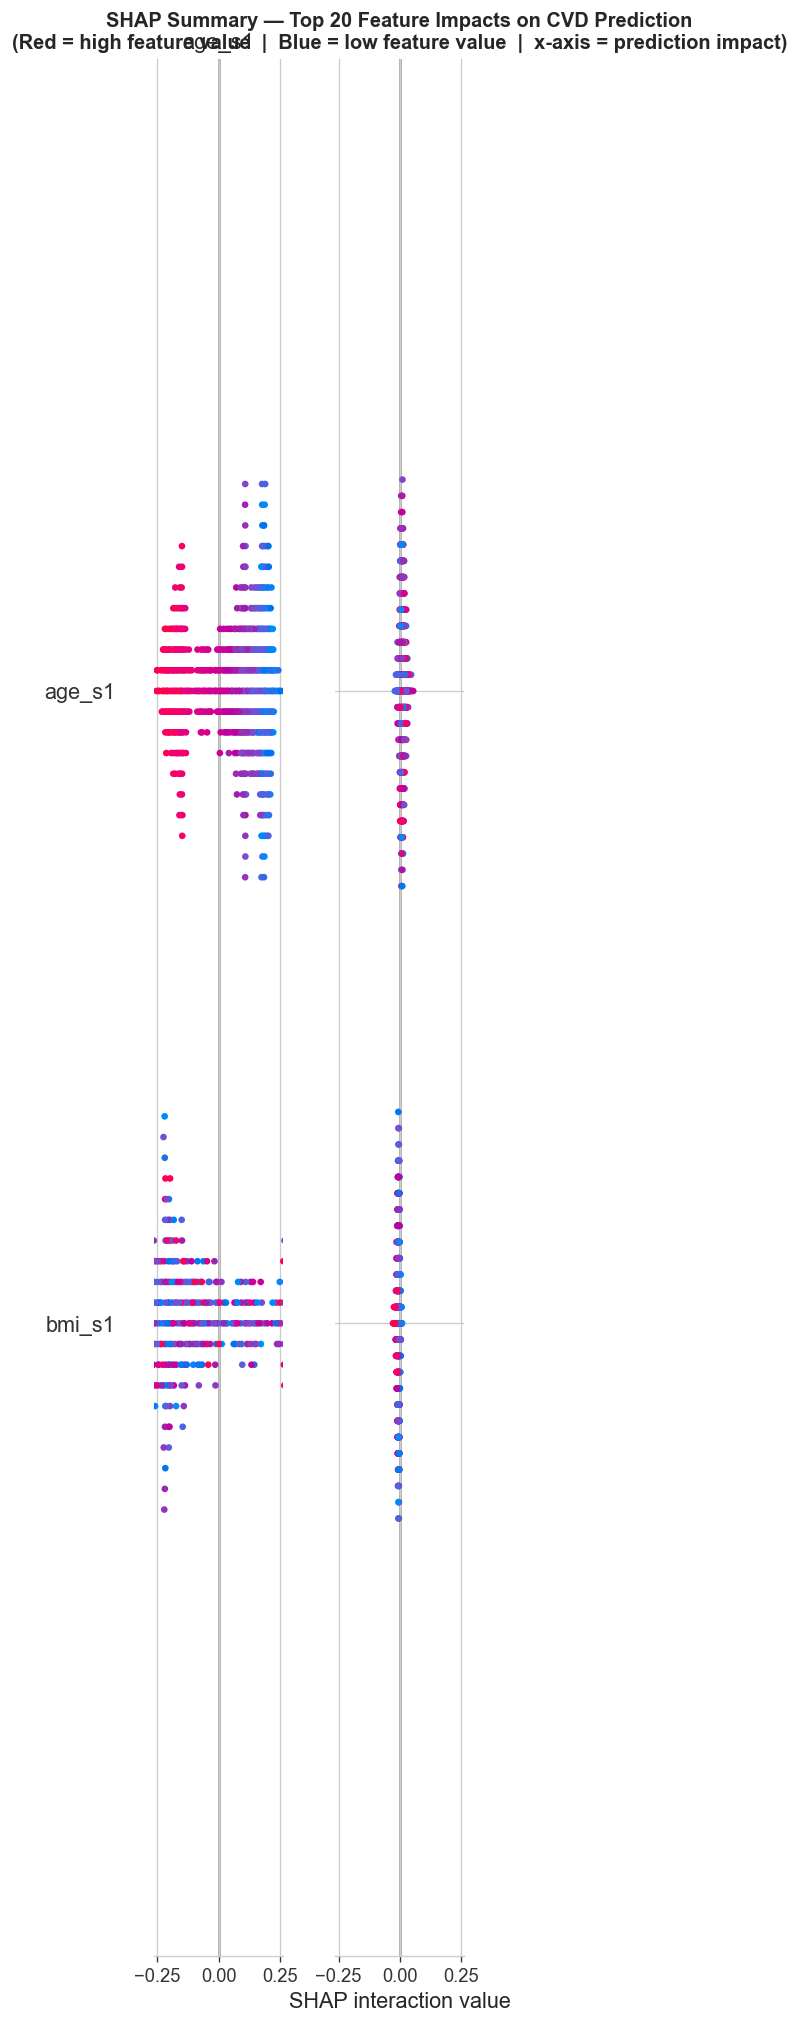

In [ ]:
# SHAP Summary
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, feature_names=FEATURES,
                  plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Feature Impacts on CVD Prediction\n'
          '(Red = high feature value  |  Blue = low feature value  |  x-axis = prediction impact)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

<Figure size 1080x840 with 0 Axes>

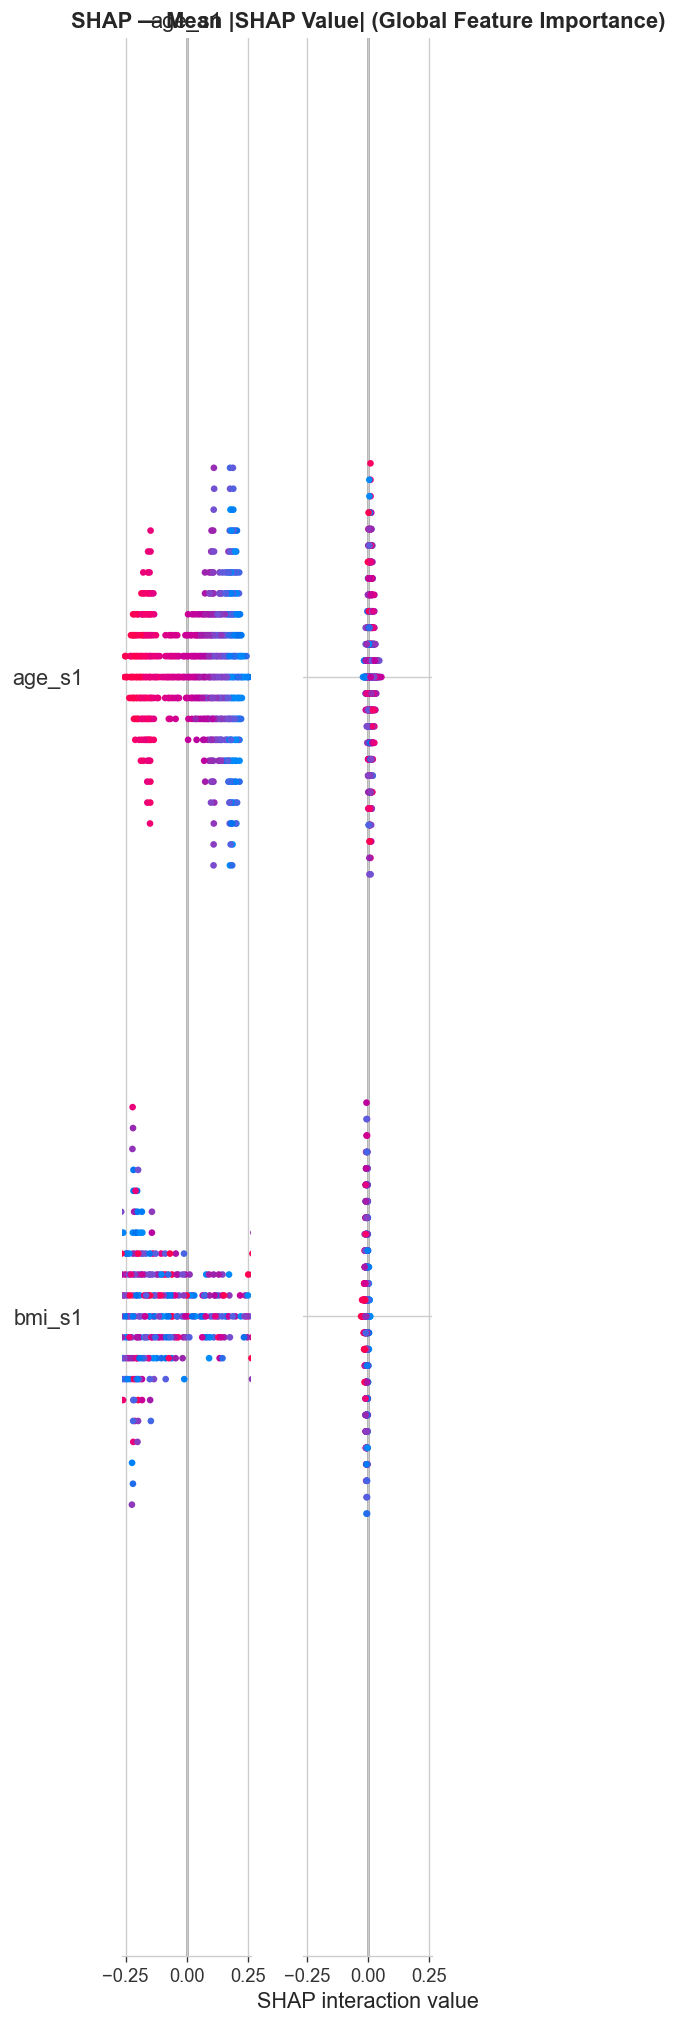

In [ ]:
#  SHAP Bar Chart — Mean |SHAP|
plt.figure(figsize=(9, 7))
shap.summary_plot(sv, X_shap, feature_names=FEATURES,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP — Mean |SHAP Value| (Global Feature Importance)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

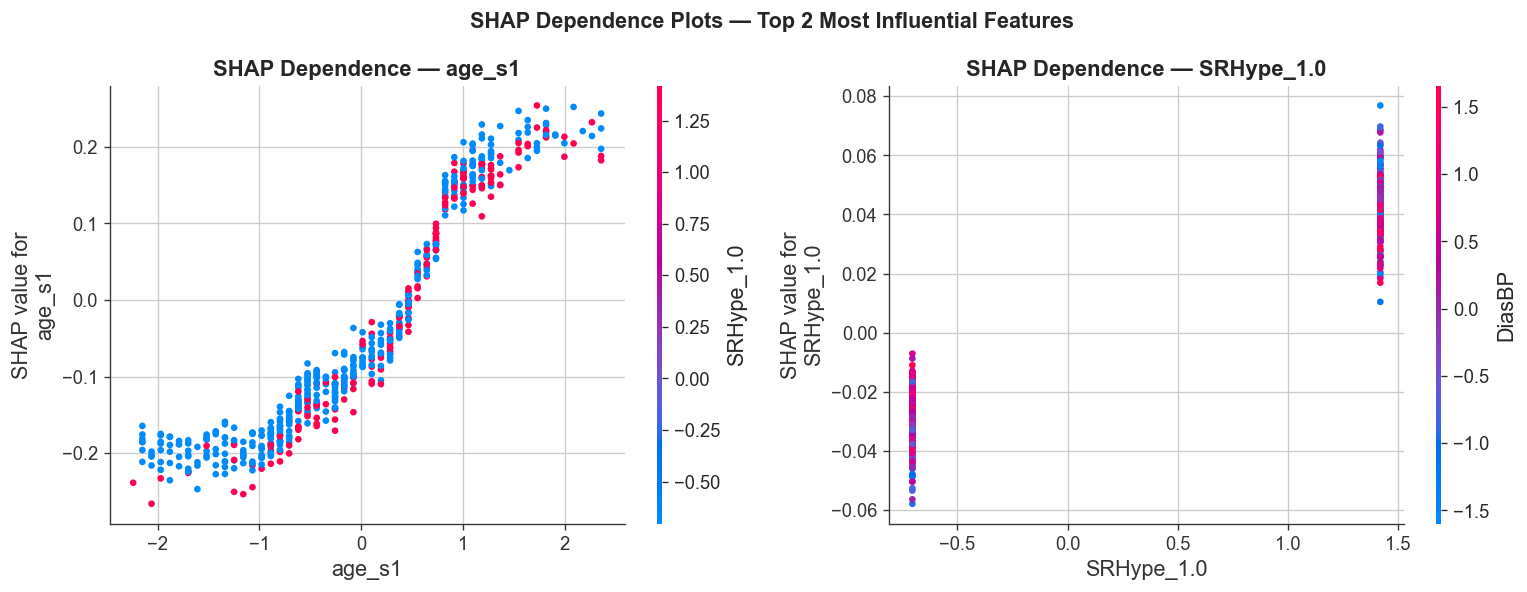

In [ ]:
# Fix: extract SHAP values for the positive class if 3D
if sv.ndim == 3:
    sv_2d = sv[:, :, 1]
else:
    sv_2d = sv

# Recompute mean absolute SHAP with the corrected array
mean_abs_shap = np.abs(sv_2d).mean(axis=0)

# SHAP Dependence Plots — Top 2 features
top2_idx = mean_abs_shap.argsort()[-2:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, idx in zip(axes, top2_idx):
    shap.dependence_plot(idx, sv_2d, X_shap, feature_names=FEATURES, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence — {FEATURES[idx]}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 2 Most Influential Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', bbox_inches='tight')
plt.show()

In [ ]:
# Ensure mean_abs_shap is 1-D (recompute from sv_2d)
if sv.ndim == 3:
    sv_2d = sv[:, :, 1]
else:
    sv_2d = sv

mean_abs_shap = np.abs(sv_2d).mean(axis=0).flatten()  # guarantees 1-D

# Unified importance table (all 3 methods)
imp_table = pd.DataFrame({
    'Feature'     : FEATURES,
    'MDI_Score'   : rf_best.feature_importances_,
    'MDI_Rank'    : pd.Series(rf_best.feature_importances_).rank(ascending=False).astype(int).values,
    'Perm_Score'  : perm.importances_mean,
    'Perm_Rank'   : pd.Series(perm.importances_mean).rank(ascending=False).astype(int).values,
    'SHAP_Score'  : mean_abs_shap,
    'SHAP_Rank'   : pd.Series(mean_abs_shap).rank(ascending=False).astype(int).values,
})
imp_table['Avg_Rank'] = imp_table[['MDI_Rank', 'Perm_Rank', 'SHAP_Rank']].mean(axis=1)
imp_table = imp_table.sort_values('Avg_Rank').round(6)

print('=== Top 15 Features — Unified Importance Ranking ===')
print(imp_table.head(15)[['Feature','MDI_Rank','Perm_Rank','SHAP_Rank','Avg_Rank','MDI_Score','Perm_Score','SHAP_Score']]
      .to_string(index=False))

=== Top 15 Features — Unified Importance Ranking ===
       Feature  MDI_Rank  Perm_Rank  SHAP_Rank  Avg_Rank  MDI_Score  Perm_Score  SHAP_Score
        age_s1         1          1          1  1.000000   0.189844    0.181703    0.137267
        SystBP         2          2          4  2.666667   0.043727    0.009761    0.025699
        DiasBP         6          3          6  5.000000   0.038246    0.007782    0.018851
          WASO         5         10         10  8.333333   0.038252    0.000642    0.011725
    SRHype_1.0        20          4          2  8.666667   0.026247    0.006483    0.033581
      gender_2        23          6          3 10.666667   0.021450    0.003092    0.031516
          Trig         9         11         14 11.333333   0.035028    0.000638    0.008095
        CgPkYr        19          7          8 11.333333   0.027979    0.001989    0.015632
        bmi_s1        12          9         21 14.000000   0.033398    0.000830    0.006166
ParRptDiab_1.0        28   

In [ ]:
# Save the trained model and preprocessing artifacts
# rf_cvd_model.sav  — the tuned Random Forest (use this for Streamlit and inference)
# scaler.sav        — StandardScaler fit on the training set
# feature_names.json — ordered list of feature names (must match model input order)
# final_metrics.json — test set performance metrics for reporting

joblib.dump(rf_best, 'rf_cvd_model.sav')
joblib.dump(scaler,  'scaler.sav')

with open('feature_names.json', 'w') as f:
    json.dump(FEATURES, f)

with open('final_metrics.json', 'w') as f:
    json.dump({
        'Accuracy'   : round(acc_tuned, 4),
        'AUC'        : round(auc_tuned, 4),
        'Precision'  : round(prec,      4),
        'Recall'     : round(rec,       4),
        'F1'         : round(f1,        4),
        'Specificity': round(tn / (tn + fp), 4),
        'CV_AUC_mean': round(cv_scores.mean(), 4),
        'CV_AUC_std' : round(cv_scores.std(),  4),
        'n_features' : len(FEATURES),
        'n_test'     : len(y_test),
        'best_params': rf_search.best_params_,
    }, f, indent=2)

print('Files saved successfully:')
print('  rf_cvd_model.sav    — tuned Random Forest classifier')
print('  scaler.sav          — StandardScaler (fit on training set only)')
print('  feature_names.json  — ordered feature list for inference')
print('  final_metrics.json  — test set performance metrics')
print()
print('To load and run inference later:')
print("  model   = joblib.load('rf_cvd_model.sav')")
print("  scaler  = joblib.load('scaler.sav')")
print("  X_new_sc = scaler.transform(X_new)")
print("  prob     = model.predict_proba(X_new_sc)[:, 1]")

Files saved successfully:
  rf_cvd_model.sav    — tuned Random Forest classifier
  scaler.sav          — StandardScaler (fit on training set only)
  feature_names.json  — ordered feature list for inference
  final_metrics.json  — test set performance metrics

To load and run inference later:
  model   = joblib.load('rf_cvd_model.sav')
  scaler  = joblib.load('scaler.sav')
  X_new_sc = scaler.transform(X_new)
  prob     = model.predict_proba(X_new_sc)[:, 1]
